# Równanie Schrödingera - Prezentacja implementacji numerycznej
*Julia Zalewska, Oliwia Marut, Natalia Chmiel*

# Architektura pakietu
Prezentowanie kodów opierają się na stworzonym przez nas pakiecie w języku Julia. 
Główny plik modułu `SchrodingerSolver.jl` spina cały projekt w spójną całość.

In [6]:
module SchrodingerSolver
    using LinearAlgebra
    include("SchrodingerSolver/src/fdm.jl")
    include("SchrodingerSolver/src/numerov.jl")
    export solve_FDM, solve_Numerov, E_analytic
end

using .SchrodingerSolver

## Metoda Różnic Skończonych (FDM) - Implementacja i Wykresy

In [4]:
using LinearAlgebra
using SparseArrays
using Plots

Poniższa funkcja buduje macierz Hamiltona dla wektora potencjału `V` rozłożonego na siatce przestrzennej `x` i rozwiązuje problem własny.

In [5]:
function solve_FDM(V::Vector{Float64}, x::Vector{Float64}, m::Float64, planck::Float64; n_states::Int=3)
    N = length(x)
    dx = x[2] - x[1]

    # Współczynnik przy drugiej pochodnej
    C = planck^2 / (2.0 * m * dx^2) 

    # Przekątna główna i poboczna
    main_diag = V .+ (2.0 * C) 
    under_diag = fill(-C, N - 1)

    # Utworzenie rzadkiej macierzy trójprzekątnej
    H = SymTridiagonal(main_diag, under_diag)
    
    # Rozwiązanie problemu własnego
    eigenvalues, eigenvectors = eigen(H)
    
    # Wybór n_states najniższych stanów
    E = eigenvalues[1:n_states]
    psi = eigenvectors[:, 1:n_states]
    
    # Normalizacja funkcji falowych w przestrzeni ciągłej
    psi = psi ./ sqrt(dx)
    
    return E, psi
end

solve_FDM (generic function with 1 method)

### Testy i wizualizacje wyników dla różnych potencjałów

## Wizualizacja wyników (Wykresy)
Poniżej prezentujemy wyniki działania metody **Różnic Skończonych (FDM)** dla kwantowego oscylatora harmonicznego ($V(x) = \frac{1}{2} k x^2$). 
Na wykresie nakładamy funkcje falowe na odpowiadające im poziomy energii.

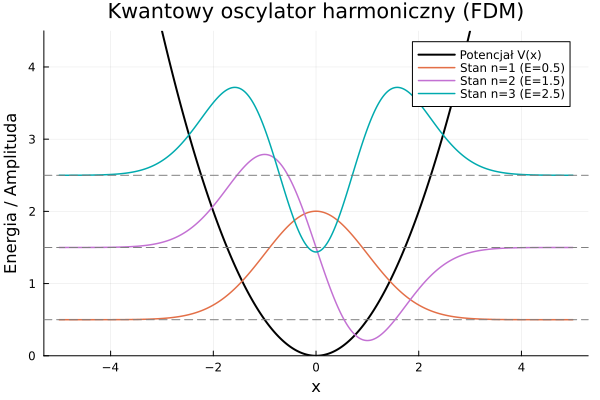

In [8]:
using Plots
using .SchrodingerSolver

x_plot = collect(range(-5.0, 5.0, length=1000))
m_plot = 1.0
planck_plot = 1.0
k_plot = 1.0

# Definicja potencjału (Oscylator harmoniczny)
V_plot = 0.5 .* k_plot .* x_plot.^2

# Rozwiązanie równania metodą FDM
energies, wavefuncs = solve_FDM(V_plot, x_plot, m_plot, planck_plot)

p = plot(x_plot, V_plot, label="Potencjał V(x)", linewidth=2, color=:black, 
         xlabel="x", ylabel="Energia / Amplituda", 
         title="Kwantowy oscylator harmoniczny (FDM)", ylims=(0, energies[3] + 2.0))

# Dodanie 3 najniższych stanów (funkcje falowe przesunięte o wartość energii E)
for i in 1:3
    plot!(p, x_plot, energies[i] .+ 2.0 .* wavefuncs[:, i], 
          label="Stan n=$i (E=$(round(energies[i], digits=2)))", linewidth=1.5)
    
    hline!(p, [energies[i]], linestyle=:dash, color=:gray, label="")
end

display(p)